In [138]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier, RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.inspection import DecisionBoundaryDisplay

# metrica
from sklearn.metrics import accuracy_score

# distancias
from scipy.spatial import distance

# Machine Learning
- Quando um modelo aprende a classificar se vai chover ou não amanhã, como ele aprende, o que é "ele aprender"?

<center>
  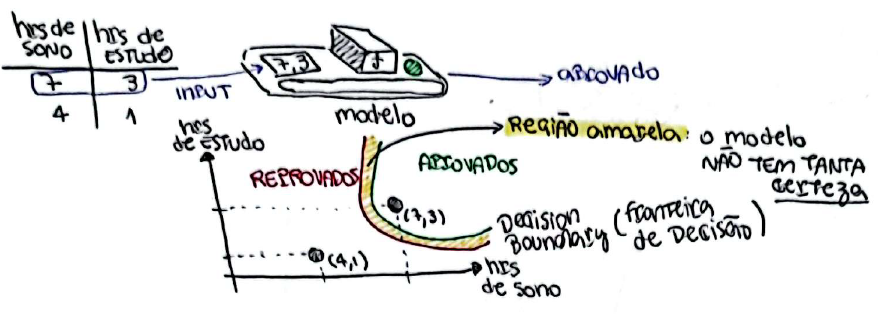
</center>

<center>
  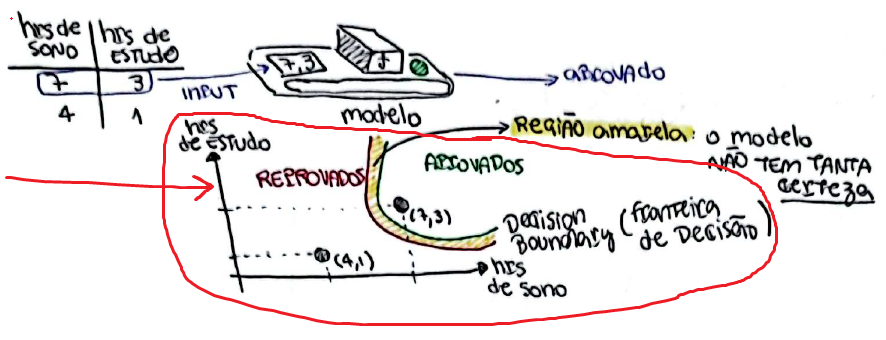
</center>

# O que é Algebra Linear
- De forma simples **Álgebra Linear** estuda espaços e as suas operações:

<center>
  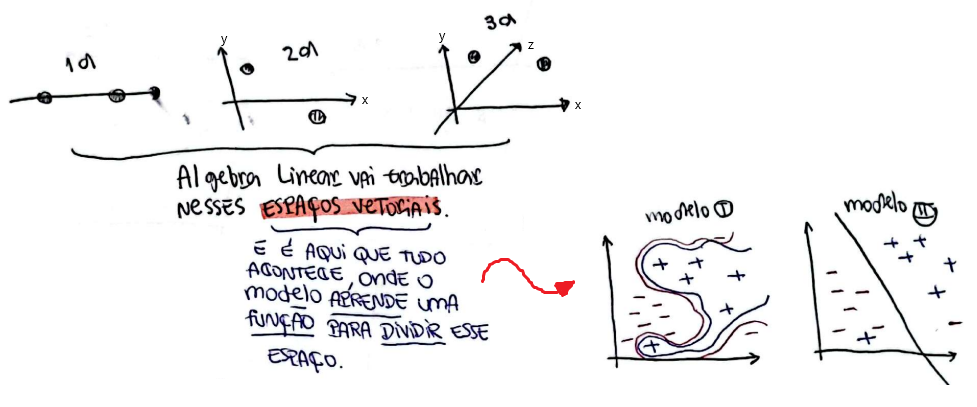
</center>

# Porque ela é importante
Porque é nesse espaço, que o modelo **APRENDE** a fazer cortes nele de tal forma que responda as perguntas que estamos interessados em responder. E **COMO** ele faz isso depende do **ALGORITMO** que estamos utilizando.

<center>
  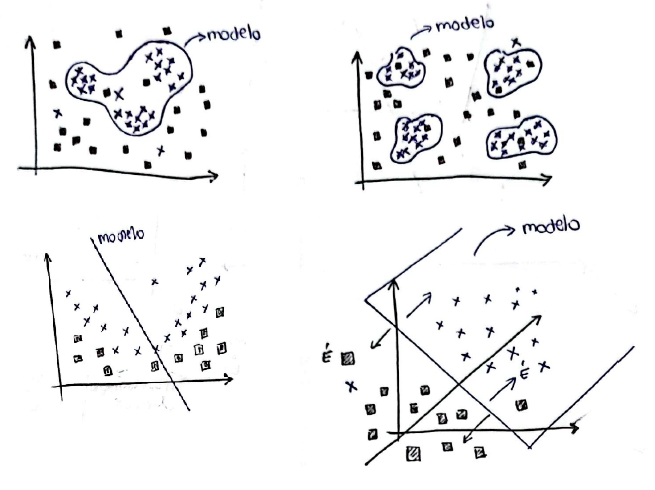
</center>

## Por exemplo:
<center>
  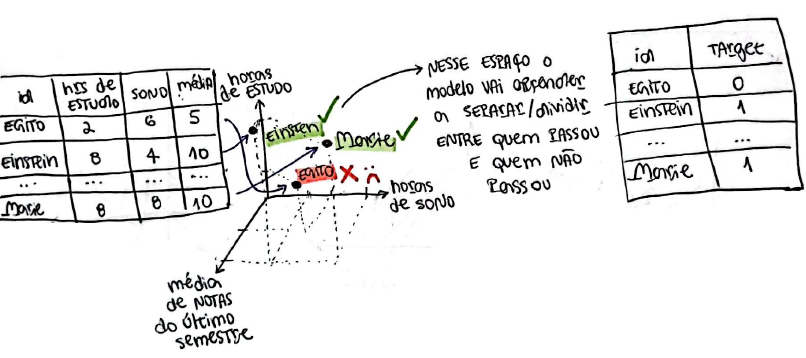
</center>

In [68]:
SEED = 42
X, y = make_moons(n_samples=1000, random_state=SEED, noise=0.35)

In [69]:
print('Qual a cara dos nossos dados:')
print(X[:10])

Qual a cara dos nossos dados:
[[-0.20196185  0.6342614 ]
 [ 1.30859918 -0.22683162]
 [ 0.68705709  0.35363491]
 [-0.1537098  -0.70682589]
 [-0.79100679  0.55740513]
 [ 0.73571659  0.15266424]
 [ 0.25653197 -0.17284425]
 [-0.20473318  0.62416123]
 [ 1.52459725 -0.38330566]
 [ 0.84551228  1.11759697]]


In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    shuffle=True,
    stratify=y,
    test_size=0.2
)

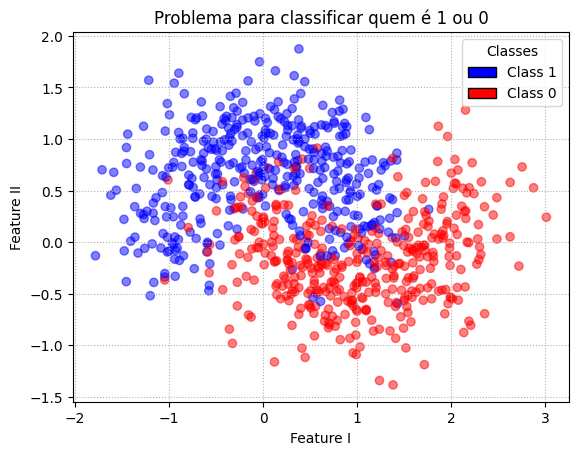

In [77]:
from matplotlib.patches import Patch
fig, ax = plt.subplots()
ax.scatter(
    X_train[:, 0],
    X_train[:, 1], 
    c=y_train, 
    cmap=plt.cm.bwr, 
    alpha=0.5
)
ax.set_xlabel('Feature I')
ax.set_ylabel('Feature II')
legend_elements = [
    Patch(facecolor='blue', edgecolor='black', label='Class 1'),
    Patch(facecolor='red', edgecolor='black', label='Class 0')
]
ax.legend(handles=legend_elements, title='Classes')
ax.grid(True, linestyle=':')
ax.set_title('Problema para classificar quem é 1 ou 0')
plt.show()

In [75]:
# modelos
# Lista de modelos
modelos = {
    "Decision Tree": DecisionTreeClassifier(max_depth=17),
    "Random Forest": RandomForestClassifier(n_estimators=20, max_depth=3),
    "AdaBoost": AdaBoostClassifier(),
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "MLP": MLPClassifier(max_iter=1000),
    "Boosting": GradientBoostingClassifier(n_estimators=20, max_depth=3)
}

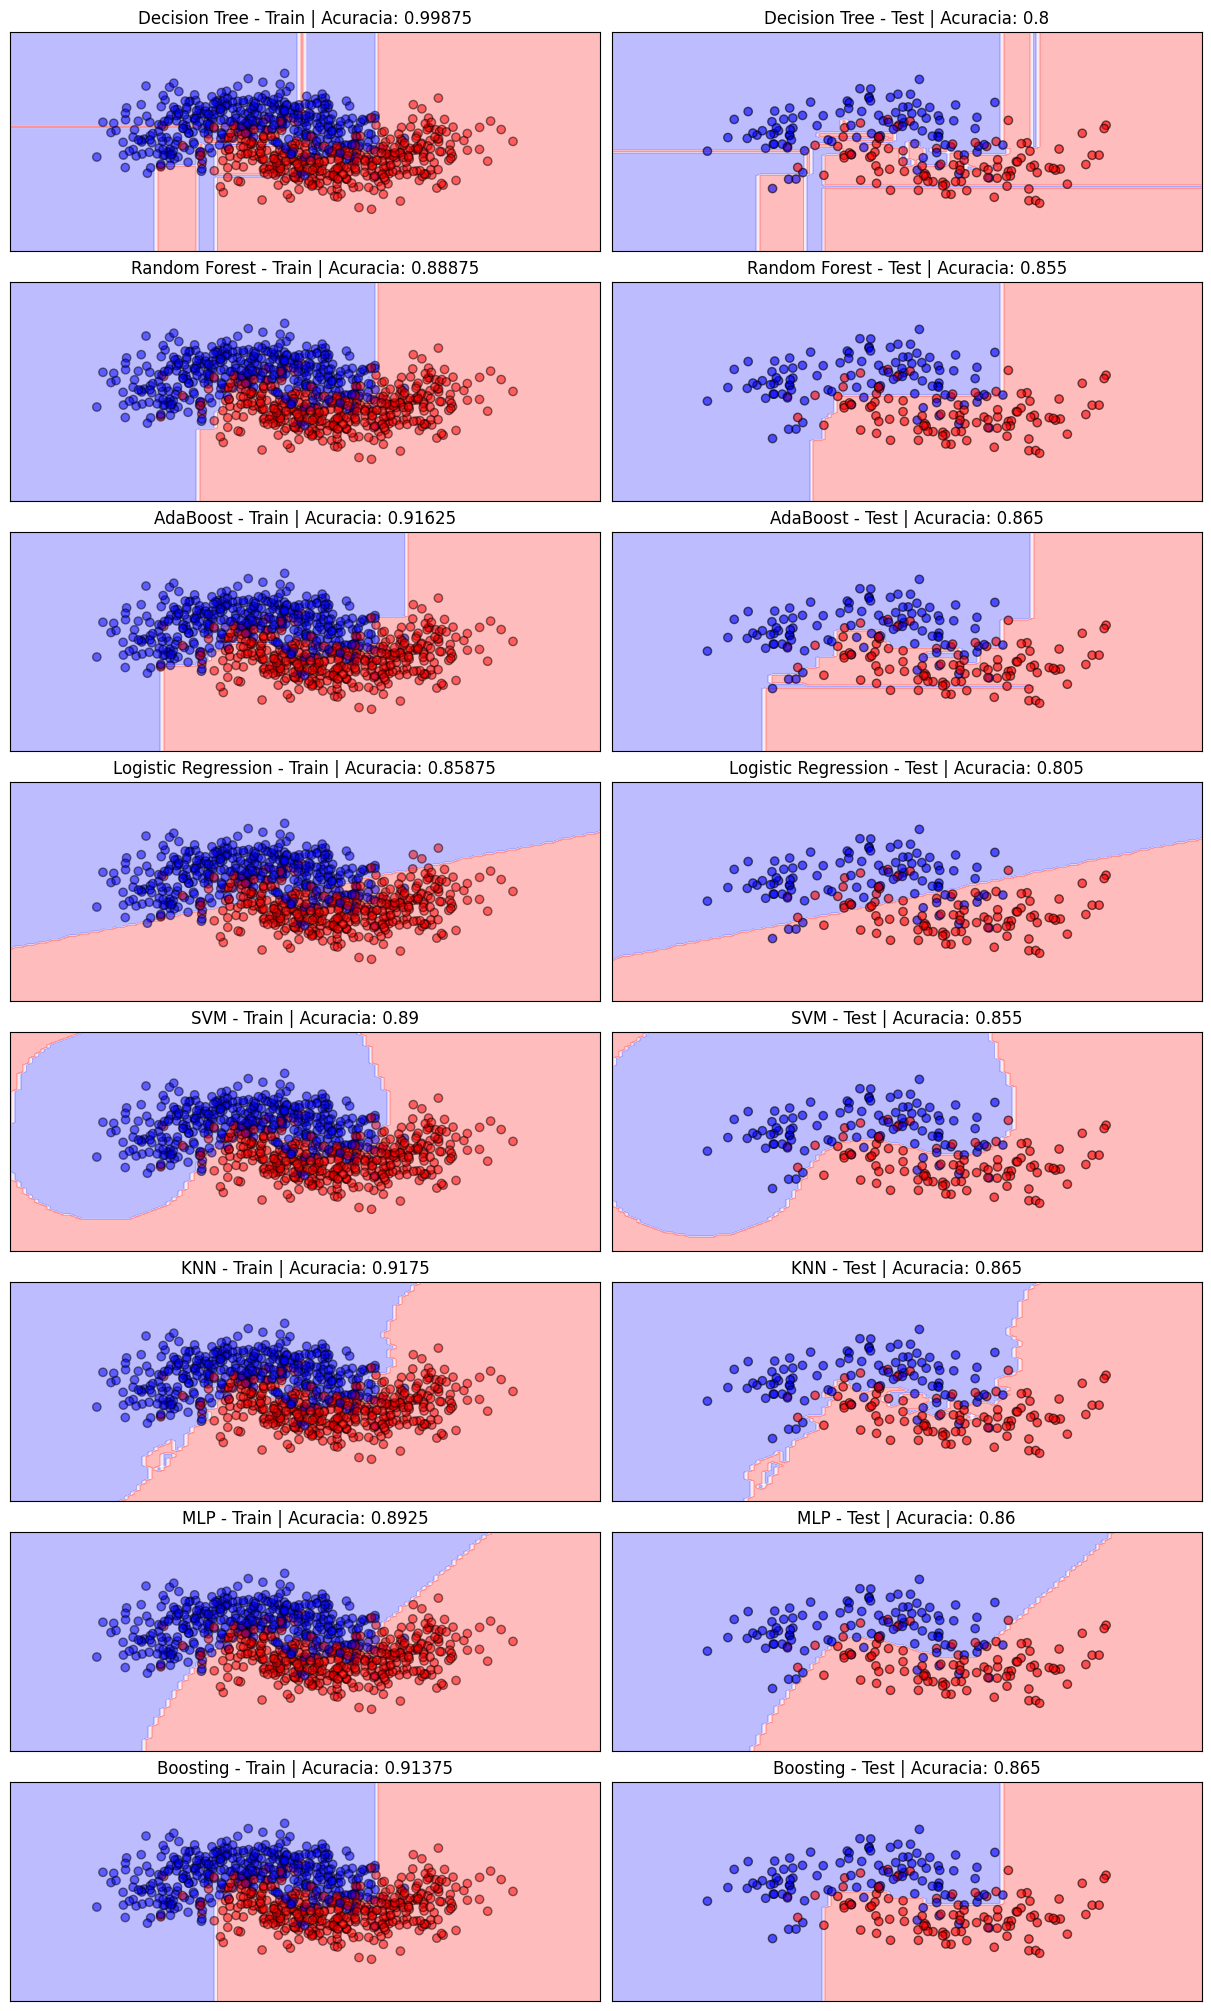

In [78]:
cmap = plt.cm.bwr
fig, axes = plt.subplots(8, 2, figsize=(12, 20), layout='constrained')
for i, (modelo_name, model) in enumerate(modelos.items()):
    # Treinamento
    model.fit(X_train, y_train)
    acc_train = model.score(X_train, y_train)
    acc_test = model.score(X_test, y_test)
    # train
    disp_train = (
        DecisionBoundaryDisplay
        .from_estimator(
            model,
            X_train,
            response_method="predict",
            cmap=cmap,
            ax=axes[i, 0],
            alpha=0.3
        )
    )
    axes[i, 0].scatter(
        X_train[:, 0], 
        X_train[:, 1], 
        c=y_train, 
        cmap=cmap, 
        edgecolor='k', 
        alpha=0.5
    )
    axes[i, 0].set_title(f"{modelo_name} - Train | Acuracia: {acc_train}")
    axes[i, 0].set_xticks([])
    axes[i, 0].set_yticks([])

    # test
    disp_test = (
        DecisionBoundaryDisplay
        .from_estimator(
            model,
            X_test,
            response_method="predict", 
            cmap=cmap, 
            ax=axes[i, 1], 
            alpha=0.3
        )
    )
    axes[i, 1].scatter(
        X_test[:, 0],
        X_test[:, 1], 
        c=y_test, 
        cmap=cmap, 
        edgecolor='k', 
        alpha=0.6
    )
    axes[i, 1].set_title(f"{modelo_name} - Test | Acuracia: {acc_test}")
    axes[i, 1].set_xticks([])
    axes[i, 1].set_yticks([])
plt.show()

# Álgebra Linear (Mais no Detalhe)
## Vetores e Matrizes

### Vetores

<center>
  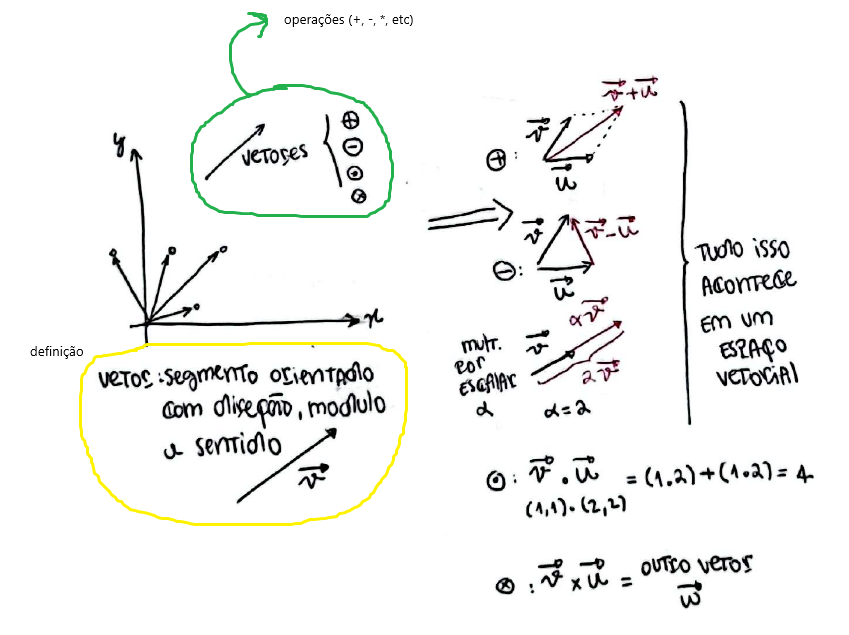
</center>

In [113]:
# vetores
u = np.array([1, 2])
v = np.array([4, 6])

In [106]:
def view_vectors(*vetores, nomes=None, cores=None):
    nomes = ['v', 'u', 'w', 't'][:len(vetores)]
    cores = ['r', 'b', 'g', 'purple'][:len(vetores)]
    
    fig, ax = plt.subplots(figsize=(8, 6))
    origin = np.array([[0], [0]])

    for vetor, nome, cor in zip(vetores, nomes, cores):
        ax.quiver(*origin, vetor[0], vetor[1], angles='xy', scale_units='xy', scale=1, color=cor)
        ax.text(vetor[0] * 1.05, vetor[1] * 1.05, nome, color=cor, fontsize=12, weight='bold')

    # Ajustar limites com base no maior valor entre os vetores
    todos = np.stack(vetores)
    xmax = np.max(todos[:, 0]) + 1
    ymax = np.max(todos[:, 1]) + 1

    ax.set_xlim(-1, xmax)
    ax.set_ylim(-1, ymax)
    ax.set_aspect('equal')
    ax.grid(True)
    ax.set_title("Espaço")
    plt.show()

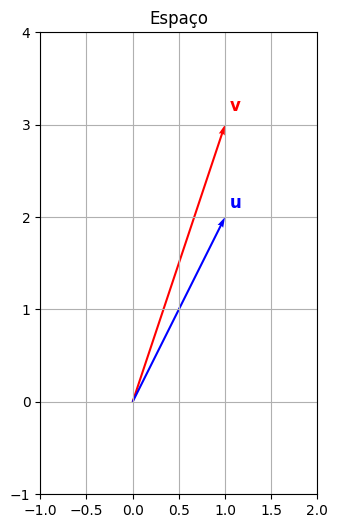

In [109]:
# visualizando 2 vetores
view_vectors(u, v)

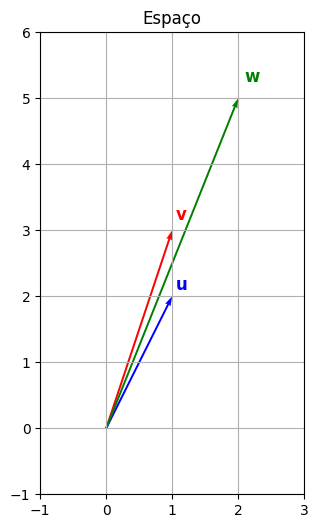

In [110]:
# soma
view_vectors(u, v, (u + v))

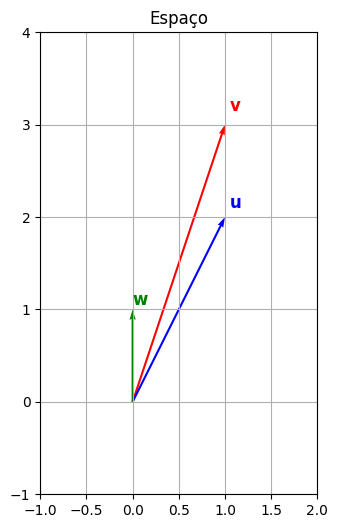

In [111]:
# subtração
view_vectors(u, v, (u - v))

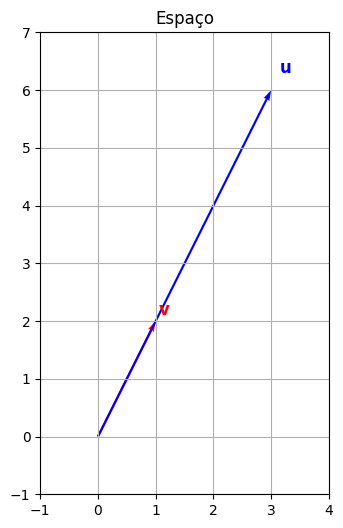

In [112]:
# multiplicação por escalar (α)
α = 3
view_vectors(v, (α * v))

In [114]:
# produto interno
u @ v

16

In [118]:
# produto vetorial
v = np.array([1, 0, 0])
u = np.array([0, 1, 0])

vu = np.cross(a, b)
print("Vetor ortogonal:", c)

Vetor ortogonal: [0 0 1]


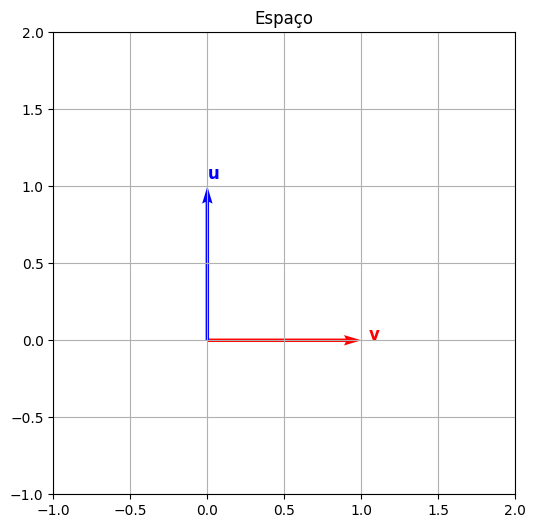

In [119]:
view_vectors(np.array([1, 0]),  np.array([0, 1]))

### Matrizes
Uma Matriz é uma *transformação linear* que mexe nos nossos vetores.

In [127]:
# matriz
M = np.array([[2, 0], [0, 1]])
# vetores
u = np.array([1, 2])
v = np.array([4, 6])

In [128]:
Mu = M @ u
Mv = M @ v

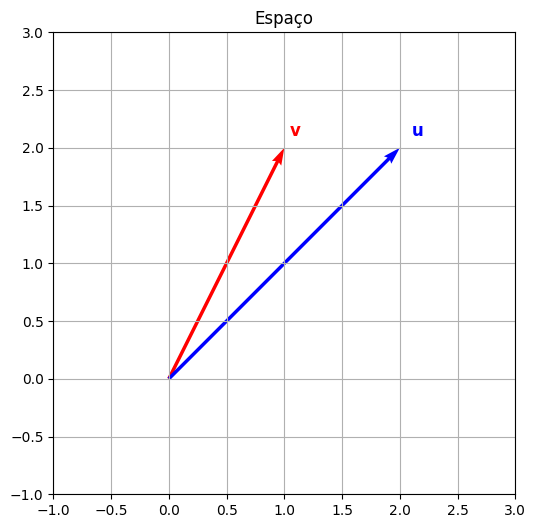

In [129]:
view_vectors(u,  Mu)

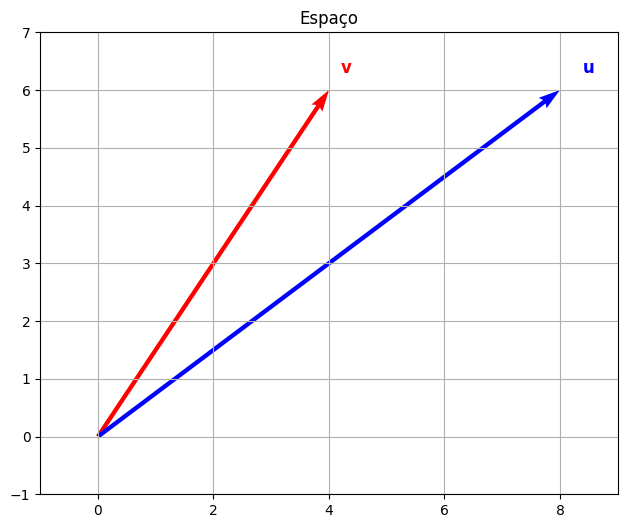

In [130]:
view_vectors(v,  Mv)

In [131]:
# multiplicação de matrizes nada mais é do que uma composição de transformações lineares
A = np.array([[1, 2], [0, 0]])
B = np.array([[3, 1], [1, 1]])

In [132]:
AB = A @ B
BA = B @ A

In [135]:
ABu = AB @ u
BAu = BA @ u

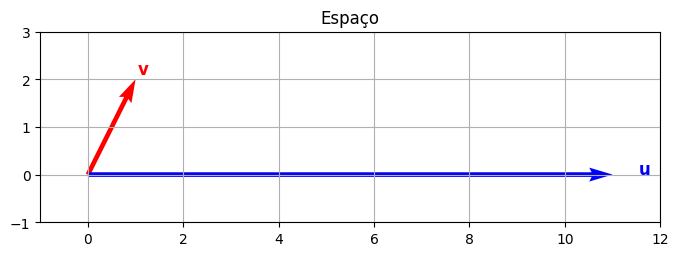

In [136]:
view_vectors(u, ABu)

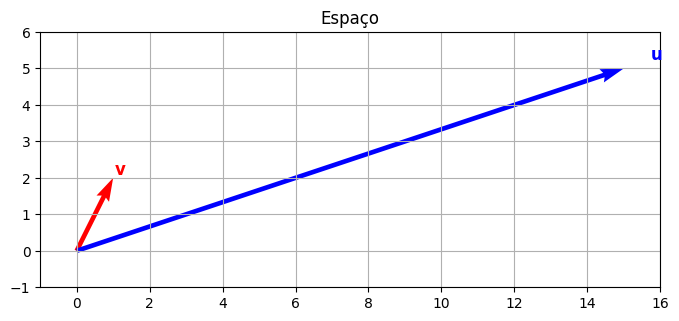

In [137]:
view_vectors(u, BAu)

E é por isso que a multiplicação de matrizes não é comutativa (AB ≠ BA)

# Distâncias
Podemos calcular a distância entre dois pontos do nosso espaço. Para isso existem diversos métodos de distancia:
- Euclidiana;
- Manhattan;
- Chebyshev;
- Minkowski;
- Cosseno.

<center>
  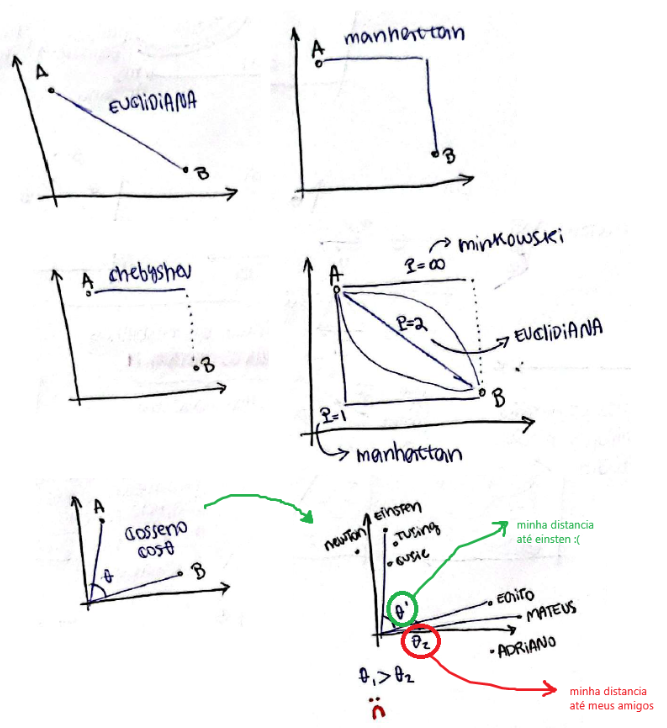
</center>

In [146]:
u = np.array([1, 0])
v = np.array([0, 1])

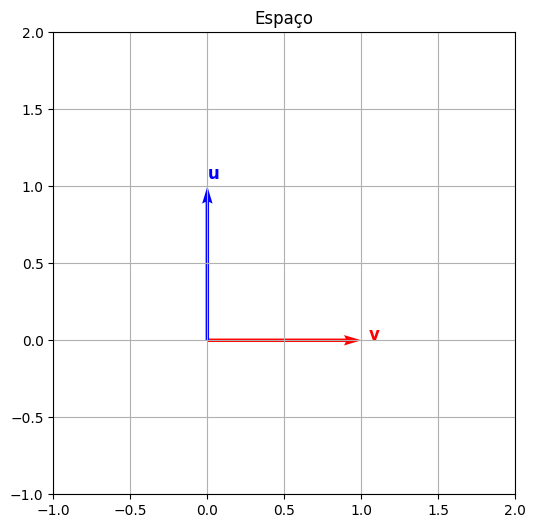

In [147]:
view_vectors(u, v)

In [148]:
# Euclidiana
distance.euclidean(u, v)

1.4142135623730951

In [149]:
# Manhattan
distance.cityblock(u, v)

2

In [150]:
# Chebyshev
distance.chebyshev(u, v)

1

In [162]:
# minkowski
print('Euclidiana, p = 2:', distance.euclidean(u, v))
print('Manhattan, p = 1:', distance.minkowski(u, v, p=1))
print('Chebyshev, p = ∞:', distance.minkowski(u, v, p=1_000_000_000))
print('Minkowski, p = 3:', distance.minkowski(u, v, p=3))

Euclidiana, p = 2: 1.4142135623730951
Manhattan, p = 1: 2.0
Chebyshev, p = ∞: 1.000000000693147
Minkowski, p = 3: 1.2599210498948732


# Um pouco mais sobre Álgebra
- transformações lineares
- paralelismo, perpendicular, ortogonal
- Distancia entre ponto e reta, ponto e plano

<center>
  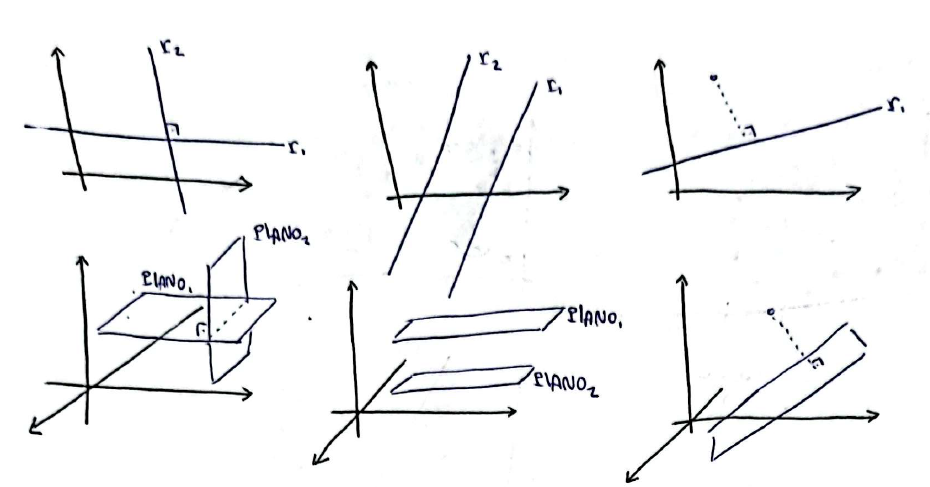
</center>

<center>
  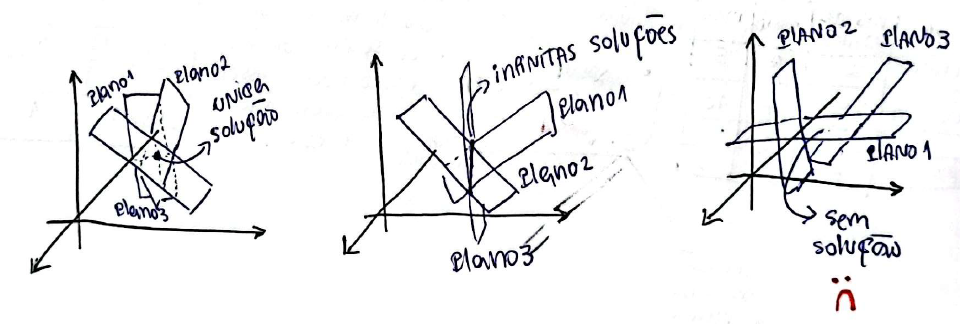
</center>

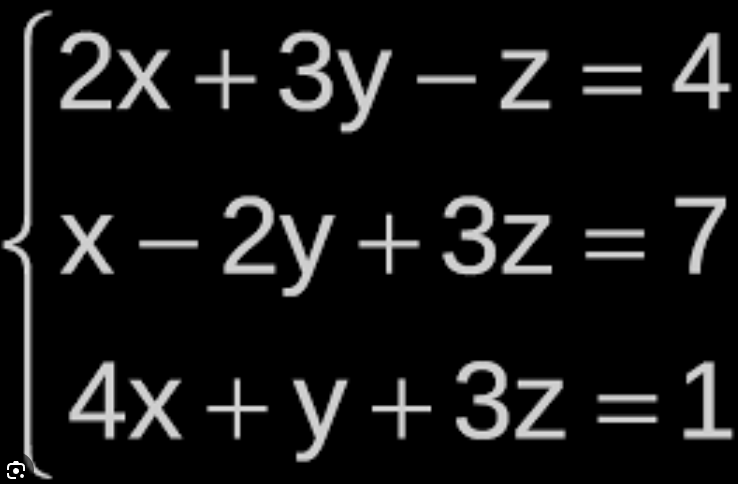 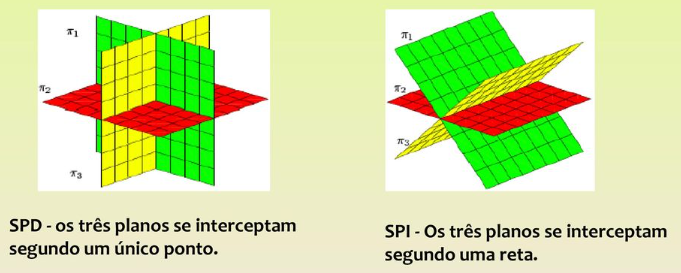 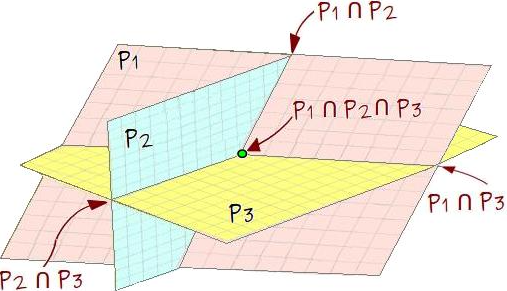

# Recomendações

**Livros:**
- Álgebra Linear - Steinbruch, Alfredo
- Geometria Analitica: Um tratamento vetorial - Ivan de Carmargo | Paulo Boulos

**Videos**
- [Essence of linear algebra](https://www.youtube.com/watch?v=fNk_zzaMoSs&list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab)
- [Álgebra Linear - Professor Possani](https://www.youtube.com/watch?v=-JcQJFNVjaA&list=PLIEzh1OveCVczEZAjhVIVd7Qs-X8ILgnI)

In [1]:
import jax.numpy as jnp
from jax import grad

def f(x):
    return 3*x**2 + 2*x + 1

dfdx = grad(f)
print(dfdx(2.0))  # 14.0


14.0


In [4]:
6 * 2 + 2

14

In [5]:
params = {
    "w": jnp.array([1.0, 2.0]),
    "b": jnp.array(0.5)
}

def f(params):
    return jnp.sum(params["w"]**2) + params["b"]**2

grads = grad(f)(params)

print(grads)


{'b': Array(1., dtype=float32, weak_type=True), 'w': Array([2., 4.], dtype=float32)}
